# Developing a LLM Router with `LLMPop`   
Authors:  
 - [Lior Gazit](https://www.linkedin.com/in/liorgazit).  
 - [Meysam Ghaffari](https://www.linkedin.com/in/meysam-ghaffari-ph-d-a2553088/).  

This Colab notebook is referenced in our book's Github repo:   
https://github.com/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition   
<a target="_blank" href="https://colab.research.google.com/github/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition/blob/main/Chapter10_notebooks/Ch10_LLM_routing.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


This notebook is taught and reviewed in our book:  
**[Mastering NLP from Foundations to Agents](https://www.amazon.com/Mastering-NLP-Foundations-Agents-Automation/dp/1806106132)**  
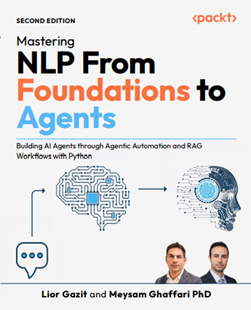



**The purpose of this notebook:**  
Designing and implementing an LLM router that dynamically selects the most suitable model for each user request based on task type, quality needs, latency, and cost constraints.  
This notebook demonstrates an end-to-end routing workflow, including model catalog setup, routing heuristics, optional paid/local model selection, and evaluation with runtime/resource considerations.  

The pipeline consists of:  
1. Installing dependencies  
1. Imports and environment setup  
1. Defining model metadata and routing criteria  
1. Building a model catalog (local and optional paid models)  
1. Implementing routing logic and decision rules  
1. Running routed prompts across representative tasks  
1. Monitoring latency and resource usage  
1. Comparing outcomes and refining routing strategy  

**Requirements:**  
* When running in Colab, use this runtime notebook setting: `Python 3, T4 GPU`  
* Set an OpenAI API key only if `allow_paid_models=True` and you want to route to OpenAI models.  

>*```Disclaimer: The content and ideas presented in this notebook are solely those of the authors and do not represent the views or intellectual property of the authors' employers.```*

**Installations:**

In [1]:
%pip -q install llmpop
%pip -q install langchain_core psutil pandas

from llmpop import install_ollama_deps
install_ollama_deps()

Installing system dependencies for Ollama: zstd, pciutils


**Imports:**

In [2]:
from __future__ import annotations
import os
import re
import time
from dataclasses import dataclass
from typing import Any, Dict, List, Optional
from getpass import getpass
from llmpop import init_llm, start_resource_monitoring

# --- Optional utilities ---
import psutil
import pandas as pd

**Settings:**

In [3]:
allow_paid_models = True

**Insert your OpenAI API key:**

In [4]:
if allow_paid_models:
  os.environ["OPENAI_API_KEY"] = getpass("Paste your OpenAI API key: ")

Paste your OpenAI API key: ··········


In [5]:
# -----------------------
# Model catalog & metadata
# -----------------------

@dataclass
class ModelSpec:
    name: str               # provider-specific model id (e.g., 'llama3:8b' or 'gpt-5.2-2025-12-11')
    provider: str           # 'ollama' or 'openai'
    size_rank: int          # smaller number = lighter/faster (heuristic)
    tags: List[str]         # ['general', 'code', 'math', 'reasoning', 'specialized:finance', ...]
    est_cost_per_1k: float  # dummy USD per 1k output tokens (for routing illustration)
    est_latency: float      # dummy seconds base latency (for routing illustration)
    notes: str = ""


def build_catalog(allow_paid_models: bool = True) -> List[ModelSpec]:
    """
    Default demo catalog.
    """
    catalog = [
        # Local (Ollama) — fast/light general chat
        ModelSpec(name="llama3.2:1b", provider="ollama", size_rank=2,
                  tags=["general"], est_cost_per_1k=0.0, est_latency=0.3,
                  notes="Local, lightweight general model"),
        # Local (Ollama) — code-aware (replace with your local favorite)
        ModelSpec(name="codellama", provider="ollama", size_rank=2,
                  tags=["code"], est_cost_per_1k=0.0, est_latency=0.35,
                  notes="Local, code-oriented"),
        # Local (Ollama) — medium general chat
        ModelSpec(name="gpt-oss:20b", provider="ollama", size_rank=3,
                  tags=["general", "code", "math", "complex"], est_cost_per_1k=0.0, est_latency=0.5,
                  notes="Local, medium size general model")]
    if allow_paid_models:
      catalog += [
          # Remote (OpenAI) — fast/cheap
          ModelSpec(name="gpt-5-mini-2025-08-07", provider="openai", size_rank=1,
                    tags=["general", "fast"], est_cost_per_1k=0.002, est_latency=0.08,
                    notes="Remote, budget/latency friendly"),
          # Remote (OpenAI)— reasoning-heavy
          ModelSpec(name="gpt-5.2-2025-12-11", provider="openai", size_rank=4,
                    tags=["reasoning", "math", "complex"], est_cost_per_1k=0.014, est_latency=0.1,
                    notes="Remote, strong reasoning")
          ]
    return catalog

# -----------------------
# Lightweight heuristics
# -----------------------

def is_complex_prompt(text: str) -> bool:
    """
    Naive complexity signal: math markers, code fences, long length, or
    words indicating step-by-step reasoning.
    """
    if len(text) > 300:
        return True
    code_markers = ["```", "def ", "class ", "SELECT ", "FROM ", "import ", "public static void"]
    math_markers = [r"\bprove\b", r"\bderive\b", r"\bO\(", r"\bintegral\b", r"[0-9]+\s*[\+\-\*\/\^]\s*[0-9]+"]
    reasoning_terms = [r"\bchain of thought\b", r"\bstep-by-step\b", r"\bthink step by step\b"]

    if any(m in text for m in code_markers):
        return True
    if any(re.search(p, text, flags=re.IGNORECASE) for p in math_markers + reasoning_terms):
        return True
    return False

def detect_specialization(text: str) -> Optional[str]:
    """
    Return a specialization tag when obvious (very naive).
    """
    pairs = {
        "code": [r"\bwrite (a|the) (python|js|sql|java|c\+\+|c#)"],
        "sql":  [r"\bSELECT\b.*\bFROM\b", r"\bCREATE TABLE\b"],
        "finance": [r"\bDCF\b", r"\bWACC\b", r"\b10-K\b"],
        "biology": [r"\bRNA\b", r"\bCRISPR\b"],
        "law": [r"\bstatute\b", r"\btort\b"],
        "math": [r"\bprove\b", r"\bintegral\b", r"\bderivative\b"],
    }
    for tag, patterns in pairs.items():
        if any(re.search(p, text, flags=re.IGNORECASE | re.DOTALL) for p in patterns):
            return tag
    return None

def snapshot_resources() -> Dict[str, Any]:
    """
    Quick resource snapshot (CPU %, available RAM GB). These values can inform routing.
    """
    try:
        cpu = psutil.cpu_percent(interval=0.2)
        mem = psutil.virtual_memory()
        avail_gb = round(mem.available / (1024**3), 2)
        return {"cpu_percent": cpu, "available_gb": avail_gb}
    except Exception:
        return {"cpu_percent": None, "available_gb": None}

def score_candidate(
    spec: ModelSpec,
    *,
    optimization: str,
    complex_prompt: bool,
    specialization: Optional[str],
    resources: Dict[str, Any]
) -> float:
    """
    Lower score = better. Combine a few simple signals:
      - If complex → prefer 'reasoning' models.
      - If specialization detected → prefer related tags (e.g., 'code', 'math').
      - Optimization: 'speed', 'cost', or 'depth' (reasoning depth).
      - If CPU is high and provider == 'ollama' → small penalty (local load).
    """
    score = 0.0

    # Based on optimization goal
    if optimization == "speed":
        score += spec.est_latency * 2.0 + spec.size_rank * 0.5
    elif optimization == "cost":
        score += spec.est_cost_per_1k * 1.5 + spec.size_rank * 0.3
    elif optimization == "depth":
        # prefer reasoning-heavy
        score += (0 if ("reasoning" in spec.tags or "complex" in spec.tags) else 1.5)
        score += spec.size_rank * 0.2
    else:
        # default blend
        score += spec.est_latency + 0.2 * spec.est_cost_per_1k

    # Complexity
    if complex_prompt and not any(t in spec.tags for t in ["reasoning", "complex", "math", "code"]):
        score += 1.0

    # Specialization
    if specialization:
        if specialization in spec.tags or f"specialized:{specialization}" in spec.tags:
            score -= 0.5  # small bonus
        else:
            # mild penalty if it doesn't look appropriate
            score += 0.3

    # Resource-aware: if CPU is busy and we're local, prefer remote
    cpu = resources.get("cpu_percent")
    if cpu is not None and cpu > 70 and spec.provider == "ollama":
        score += 0.8

    # If RAM is very low and spec is large local model (size_rank>=3), penalize
    avail_gb = resources.get("available_gb")
    if avail_gb is not None and avail_gb < 2.0 and spec.provider == "ollama" and spec.size_rank >= 3:
        score += 0.7

    return score

# -----------------------
# Dispatch
# -----------------------

def init_model(spec: ModelSpec):
    """
    Initialize a ChatModel via LLMPop's init_llm().
    For Ollama, auto_serve/auto_install/pull are enabled to make the demo smoother.
    For OpenAI, use env OPENAI_API_KEY or pass provider_kwargs with api_key.
    """
    if spec.provider == "ollama":
        return init_llm(
            model=spec.name,
            provider="ollama",
            provider_kwargs={
                "auto_install": True,
                "auto_serve": True,
                "pull": True,
            },
            temperature=0.0,
        )  # :contentReference[oaicite:2]{index=2}

    elif spec.provider == "openai":
        return init_llm(
            model=spec.name,
            provider="openai",
            temperature=0.0,
        )  # :contentReference[oaicite:3]{index=3}

    else:
        raise ValueError(f"Unknown provider: {spec.provider}")

def call_model(chat_model, user_prompt: str, system_msg: str = "You are a helpful assistant."):
    """
    Call a LangChain ChatModel returned by init_llm(). Keep it simple with a short system + human turn.
    """
    from langchain_core.messages import SystemMessage, HumanMessage
    # Return raw content; for pure string you could add StrOutputParser (see guide). :contentReference[oaicite:4]{index=4}
    result = chat_model.invoke([SystemMessage(content=system_msg), HumanMessage(content=user_prompt)])
    return getattr(result, "content", str(result))

# -----------------------
# Main router
# -----------------------

def route_and_dispatch(
    prompt: str,
    *,
    conversation_ctx: Optional[List[Dict[str, Any]]] = None,
    optimization: str = "speed",   # 'speed' | 'cost' | 'depth'
    runtime_info: Optional[Dict[str, Any]] = None,
    # csv_path: str = "Ollama models by size and call name (a limited list).csv",
    allow_paid_models: bool = True
) -> Dict[str, Any]:
    """
    Core router: choose a model and execute the call. Returns a dict with
    selection details and the model output.
    """
    catalog = build_catalog(allow_paid_models)

    complex_prompt = is_complex_prompt(prompt)
    specialization = detect_specialization(prompt)
    resources = snapshot_resources()

    # Incorporate any runtime quotas into a tiny penalty (dummy)
    quotas = (runtime_info or {}).get("api_quotas", {})
    openai_quota_low = quotas.get("openai_remaining", 1000) < 50
    ollama_quota_low = quotas.get("ollama_remaining", 1000) < 10

    # Score each candidate
    scored = []
    for spec in catalog:
        s = score_candidate(spec,
                            optimization=optimization,
                            complex_prompt=complex_prompt,
                            specialization=specialization,
                            resources=resources)
        # Quotas as penalties (illustrative)
        if spec.provider == "openai" and openai_quota_low:
            s += 1.0
        if spec.provider == "ollama" and ollama_quota_low:
            s += 0.5
        scored.append((s, spec))

    scored.sort(key=lambda x: x[0])
    chosen = scored[0][1]

    # Try to init and call; fall back if needed
    error = None
    response = None
    try:
        chat_model = init_model(chosen)
        response = call_model(chat_model, prompt)
    except Exception as e:
        error = f"{type(e).__name__}: {e}"
        # Fallback: attempt the next candidate
        if len(scored) > 1:
            try:
                alt = scored[1][1]
                chat_model = init_model(alt)
                response = call_model(chat_model, prompt)
                chosen = alt
            except Exception as e2:
                response = f"[Router demo fallback] Could not reach any LLM. Last error: {type(e2).__name__}: {e2}"

    return {
        "chosen_model": chosen.name,
        "provider": chosen.provider,
        "notes": chosen.notes,
        "complex_prompt": complex_prompt,
        "specialization": specialization,
        "optimization": optimization,
        "resources": resources,
        "error": error,
        "response": response,
    }

In [6]:

# -----------------------
# Demo entrypoint
# -----------------------

def main(prompt: str,
      conversation_ctx: Optional[List[Dict[str, Any]]] = None,
      optimization: str = "speed",   # 'speed' | 'cost' | 'depth'
      runtime_info: Optional[Dict[str, Any]] = None,
      allow_paid_models: bool = True):
    # # Optional: start a background resource logger (1 minute, every 5s) — for demo visibility.
    # # This is purely illustrative; uncomment if desired.
    # try:
    #     _ = start_resource_monitoring(logfile="resource_usage.log", duration=60, interval=5)  # :contentReference[oaicite:5]{index=5}
    # except Exception:
    #     pass

    result = route_and_dispatch(
        prompt=prompt,
        conversation_ctx=conversation_ctx,
        optimization=optimization,
        runtime_info=runtime_info,
        allow_paid_models=allow_paid_models
    )

    print("\n=== Router Decision ===")
    print(f"Chosen: {result['chosen_model']} (provider={result['provider']})")
    print(f"Notes:  {result['notes']}")
    print(f"Complex prompt? {result['complex_prompt']}; specialization: {result['specialization']}")
    print(f"Optimization: {result['optimization']}")
    print(f"Resources snapshot: {result['resources']}")
    if result["error"]:
        print(f"Init error (first try): {result['error']}")

    print("\n=== Model Output ===")
    print(str(result["response"]))

if __name__ == "__main__":
    # Sample inputs (edit these to experiment)
    prompt = (
        "Write a short Python function that returns the nth Fibonacci number, "
        "then analyze the time complexity."
    )
    conversation_ctx = [{"role": "system", "content": "You are concise."}]
    optimization = "speed"  # try 'speed', 'cost', or 'depth'

    # Dummy runtime info: pretend OpenAI quota is healthy; Ollama is unlimited.
    runtime_info = {"api_quotas": {"openai_remaining": 500, "ollama_remaining": 9999}}
    allow_paid_models = True
    main(prompt, conversation_ctx, optimization, runtime_info, allow_paid_models)

🚀 Setting up remote OpenAI chat model…
Installing langchain-openai...
All done setting up OpenAI (ChatOpenAI).


=== Router Decision ===
Chosen: gpt-5-mini-2025-08-07 (provider=openai)
Notes:  Remote, budget/latency friendly
Complex prompt? False; specialization: None
Optimization: speed
Resources snapshot: {'cpu_percent': 9.8, 'available_gb': 11.38}

=== Model Output ===
Here's a short, simple Python function that returns the nth Fibonacci number (with F0 = 0, F1 = 1):

def fib(n):
    if n < 0:
        raise ValueError("n must be non-negative")
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a

Time complexity (arithmetic model, assuming each integer addition is O(1)):
- The loop runs n times, each step does a constant amount of work → O(n) time.
- Space complexity is O(1) (only a few variables).

Notes and refinements:
- The naive recursive implementation (fib(n) = fib(n-1) + fib(n-2) without memoization) is exponential time, about O(φ^n) where φ ≈ 1.618.
-

----

## Evaluating Various Scenarios

### Optimize speed: coding task  
This differs from the above as we now **Exclude paid remote models**, sticking with local models.

In [7]:
# Sample inputs (edit these to experiment)
prompt = (
    "Write a short Python function that returns the nth Fibonacci number, "
    "then analyze the time complexity."
)
conversation_ctx = [{"role": "system", "content": "You are concise."}]
optimization = "speed"  # try 'speed', 'cost', or 'depth'

# Dummy runtime info: pretend OpenAI quota is healthy; Ollama is unlimited.
runtime_info = {"api_quotas": {"openai_remaining": 500, "ollama_remaining": 9999}}
allow_paid_models = False
main(prompt, conversation_ctx, optimization, runtime_info, allow_paid_models)

🚀 Installing Ollama...
🚀 Starting Ollama server...
→ Ollama PID: 1874
⏳ Waiting for Ollama to be ready…
Ready!

🚀 Pulling model 'llama3.2:1b'…
All done setting up Ollama (ChatOllama).


=== Router Decision ===
Chosen: llama3.2:1b (provider=ollama)
Notes:  Local, lightweight general model
Complex prompt? False; specialization: None
Optimization: speed
Resources snapshot: {'cpu_percent': 2.4, 'available_gb': 11.06}

=== Model Output ===
**Fibonacci Function and Time Complexity Analysis**

Here's a simple Python function to calculate the nth Fibonacci number using recursion:

```python
def fibonacci(n):
    """
    Returns the nth Fibonacci number.

    Args:
        n (int): The position of the Fibonacci number to return.

    Returns:
        int: The nth Fibonacci number.
    """
    if n <= 0:
        raise ValueError("n must be a positive integer")
    elif n == 1:
        return 0
    elif n == 2:
        return 1
    else:
        return fibonacci(n-1) + fibonacci(n-2)
```

**Time 

### Optimize depth: coding task

In [8]:
# Sample inputs (edit these to experiment)
prompt = (
    "Write a short Python function that returns the nth Fibonacci number, "
    "then analyze the time complexity."
)
conversation_ctx = [{"role": "system", "content": "You are concise."}]
optimization = "depth"  # try 'speed', 'cost', or 'depth'

# Dummy runtime info: pretend OpenAI quota is healthy; Ollama is unlimited.
runtime_info = {"api_quotas": {"openai_remaining": 500, "ollama_remaining": 9999}}
allow_paid_models = True
main(prompt, conversation_ctx, optimization, runtime_info, allow_paid_models)

🚀 Starting Ollama server...
→ Ollama PID: 2308
⏳ Waiting for Ollama to be ready…
Ready!

🚀 Pulling model 'gpt-oss:20b'…
All done setting up Ollama (ChatOllama).


=== Router Decision ===
Chosen: gpt-oss:20b (provider=ollama)
Notes:  Local, medium size general model
Complex prompt? False; specialization: None
Optimization: depth
Resources snapshot: {'cpu_percent': 65.0, 'available_gb': 10.4}

=== Model Output ===
Here’s a compact, **iterative** implementation that returns the *n*‑th Fibonacci number (with the convention `fib(0)=0`, `fib(1)=1`):

```python
def fib(n: int) -> int:
    """Return the n‑th Fibonacci number (0‑based)."""
    if n < 0:
        raise ValueError("n must be non‑negative")
    a, b = 0, 1          # a = fib(0), b = fib(1)
    for _ in range(n):
        a, b = b, a + b  # shift one step forward
    return a
```

### How it works
* `a` always holds the current Fibonacci number `fib(k)`.
* `b` holds the next one `fib(k+1)`.
* Each loop iteration moves one step forwar

### Optimize cost: Math puzzle

In [9]:
# Sample inputs (edit these to experiment)
prompt = (
    "Prove that the squary root of 2 is irrational."
    "Then simplify it in one sentence for a 6 year old."
)
conversation_ctx = [{"role": "system", "content": "You are concise."}]
optimization = "cost"  # try 'speed', 'cost', or 'depth'

# Dummy runtime info: pretend OpenAI quota is healthy; Ollama is unlimited.
runtime_info = {"api_quotas": {"openai_remaining": 500, "ollama_remaining": 9999}}
allow_paid_models = True
main(prompt, conversation_ctx, optimization, runtime_info, )

🚀 Starting Ollama server...
→ Ollama PID: 3482
⏳ Waiting for Ollama to be ready…
Ready!

🚀 Pulling model 'gpt-oss:20b'…
All done setting up Ollama (ChatOllama).


=== Router Decision ===
Chosen: gpt-oss:20b (provider=ollama)
Notes:  Local, medium size general model
Complex prompt? True; specialization: math
Optimization: cost
Resources snapshot: {'cpu_percent': 5.0, 'available_gb': 8.38}

=== Model Output ===
**Proof that \(\sqrt{2}\) is irrational**

Assume, for the sake of contradiction, that \(\sqrt{2}\) *is* rational.  
Then we can write it as a fraction in lowest terms:

\[
\sqrt{2}=\frac{p}{q}\qquad\text{with }p,q\in\mathbb Z,\; q>0,\; \gcd(p,q)=1 .
\]

Square both sides:

\[
2=\frac{p^{2}}{q^{2}}\quad\Longrightarrow\quad p^{2}=2q^{2}.
\]

So \(p^{2}\) is an even number (it equals twice another integer).  
If a square is even, its base must be even, so \(p\) is even.  
Write \(p=2k\) for some integer \(k\). Substitute back:

\[
(2k)^{2}=2q^{2}\quad\Longrightarrow\quad 4k^{2}=2q^{

### Optimize speed: Math puzzle


In [10]:
# Sample inputs (edit these to experiment)
prompt = (
    "Prove that the squary root of 2 is irrational."
    "Then simplify it in one sentence for a 6 year old."
)
conversation_ctx = [{"role": "system", "content": "You are concise."}]
optimization = "speed"  # try 'speed', 'cost', or 'depth'

# Dummy runtime info: pretend OpenAI quota is healthy; Ollama is unlimited.
runtime_info = {"api_quotas": {"openai_remaining": 500, "ollama_remaining": 9999}}
allow_paid_models = True
main(prompt, conversation_ctx, optimization, runtime_info, )

🚀 Setting up remote OpenAI chat model…
All done setting up OpenAI (ChatOpenAI).


=== Router Decision ===
Chosen: gpt-5.2-2025-12-11 (provider=openai)
Notes:  Remote, strong reasoning
Complex prompt? True; specialization: math
Optimization: speed
Resources snapshot: {'cpu_percent': 2.6, 'available_gb': 8.28}

=== Model Output ===
### Proof that \(\sqrt{2}\) is irrational (classic contradiction proof)

Assume, for the sake of contradiction, that \(\sqrt{2}\) is rational.  
Then it can be written as a fraction in **lowest terms**:
\[
\sqrt{2}=\frac{a}{b}
\]
where \(a\) and \(b\) are integers, \(b\neq 0\), and the fraction \(\frac{a}{b}\) has no common factor other than 1.

Square both sides:
\[
2=\frac{a^2}{b^2}
\]
Multiply by \(b^2\):
\[
2b^2=a^2
\]
So \(a^2\) is even, which implies \(a\) is even (because the square of an odd number is odd).  
Thus \(a=2k\) for some integer \(k\).

Substitute \(a=2k\) into \(2b^2=a^2\):
\[
2b^2=(2k)^2=4k^2
\]
Divide by 2:
\[
b^2=2k^2
\]
So \(b^2\) is ev

### Optimize speed: Math puzzle
Excluding paid remote models, sticking with local models.

In [11]:
# Sample inputs (edit these to experiment)
prompt = (
    "Prove that the squary root of 2 is irrational."
    "Then simplify it in one sentence for a 6 year old."
)
conversation_ctx = [{"role": "system", "content": "You are concise."}]
optimization = "cost"  # try 'speed', 'cost', or 'depth'

# Dummy runtime info: pretend OpenAI quota is healthy; Ollama is unlimited.
runtime_info = {"api_quotas": {"openai_remaining": 500, "ollama_remaining": 9999}}
allow_paid_models = False
main(prompt, conversation_ctx, optimization, runtime_info, )

🚀 Starting Ollama server...
→ Ollama PID: 3595
⏳ Waiting for Ollama to be ready…
Ready!

🚀 Pulling model 'gpt-oss:20b'…
All done setting up Ollama (ChatOllama).


=== Router Decision ===
Chosen: gpt-oss:20b (provider=ollama)
Notes:  Local, medium size general model
Complex prompt? True; specialization: math
Optimization: cost
Resources snapshot: {'cpu_percent': 59.0, 'available_gb': 8.29}

=== Model Output ===
**Proof that \(\sqrt{2}\) is irrational**

Assume, for contradiction, that \(\sqrt{2}\) is rational.  
Then there exist coprime positive integers \(p\) and \(q\) (with no common factor other than 1) such that  

\[
\sqrt{2}=\frac{p}{q}\quad\Longrightarrow\quad 2=\frac{p^{2}}{q^{2}}\quad\Longrightarrow\quad p^{2}=2q^{2}.
\]

Thus \(p^{2}\) is even, so \(p\) itself must be even.  
Write \(p=2k\) for some integer \(k\). Substituting gives

\[
(2k)^{2}=2q^{2}\quad\Longrightarrow\quad 4k^{2}=2q^{2}\quad\Longrightarrow\quad q^{2}=2k^{2}.
\]

Now \(q^{2}\) is even, so \(q\) is even as w